In [1]:
# jax ecosystem
import jax

jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_enable_x64", True)
print(jax.local_devices()[0].device_kind)

from jax import numpy as np, tree as jtu
import zodiax as zdx
from zodiax.optimisation import sgd, adam
import amigo
import dorito

# other helpful libraries
import numpy
import os
import astropy

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots  # to use matplotlib style "science"

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

NVIDIA GeForce RTX 2080 Ti


/home/max/code/amigo/src/amigo/optical_models.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    path = "/media/morgana1/snert/max/"
elif gethostname() == "AJQ4YHQH9TX":
    path = "/Volumes/morgana1/snert/max/"
else:
    path = "/fred/oz440/max/"


EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    "F430M",
    "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

In [10]:
import zodiax as zdx


class Exposure(zdx.Base):
    source: str
    filter: str
    prog: str
    pwcpos: float

    def __init__(self, file, prog):
        head = file[0].header
        self.source = head["TARGPROP"]
        self.filter = head["FILTER"]
        self.pwcpos = head["PWCPOS"]
        self.prog = prog

In [16]:
sources = [
    # "NGC1068",
    "IO",
    "WR137",
    "PDS70",
    "HD135344B",
    "AB-DOR",
    "NUHOR",
]
exps = []
for source in sources:
    data_path = os.path.join(path, f"data/JWST/{source}/calslope/")
    uncal_path = os.path.join(path, f"data/JWST/{source}/uncal/")
    amigo_cache = os.path.join(path, "data/amigo_files/")

    cache = os.path.join(amigo_cache, "v_0.0.10/")
    output_path = os.path.join(amigo_cache, f"outputs/{source}/")

    files = sorted(
        file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
    )
    exps += [Exposure(file, prog=source) for file in files]

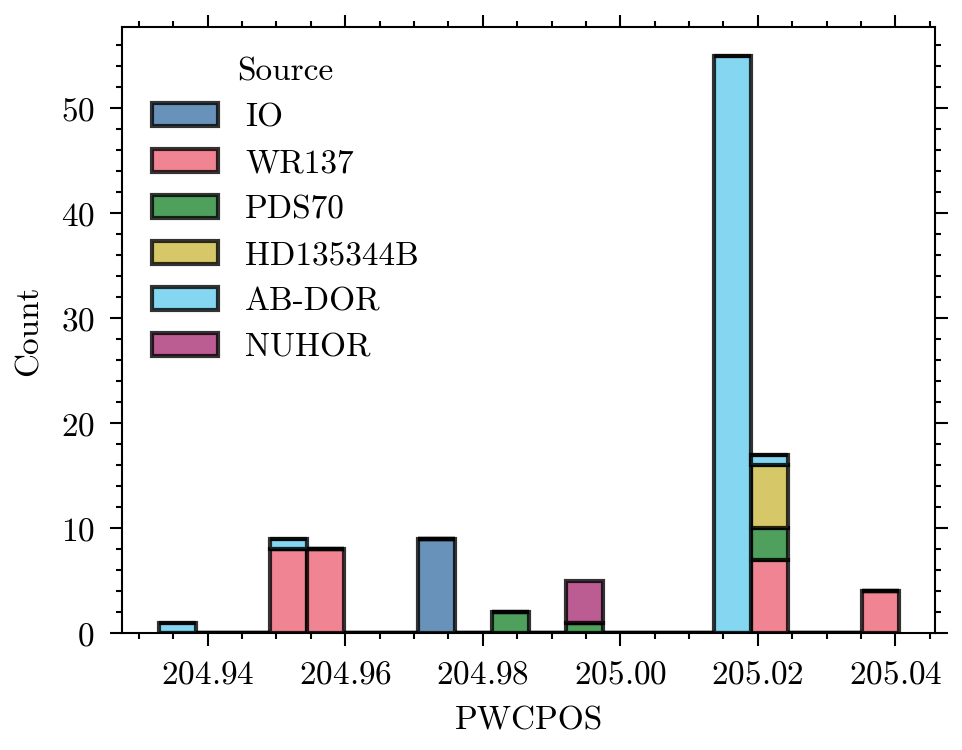

In [17]:
import matplotlib.pyplot as plt

targets = list(set([exp.source for exp in exps]))
bins = 20  # same as your previous histogram

# Collect pwcpos values by source
values_by_source = [
    np.array([exp.pwcpos for exp in exps if exp.prog == src]) for src in sources
]

# Plot stacked histogram
plt.hist(
    values_by_source,
    bins=bins,
    label=sources,
    # label=targets,
    stacked=True,
    edgecolor="black",
    alpha=0.8,
)

# # Optional: median line over total distribution
# plt.axvline(np.median(pwcpos), color="k", linestyle="--", label="Median PWCPOS")

plt.xlabel("PWCPOS")
plt.ylabel("Count")
# plt.xlim(204, 206)
# plt.title(f"PWCPOS Distribution by Source (Median: {np.median(pwcpos):.2f})")
plt.legend(title="Source")
plt.show()